# 1. Linear Regression Impact on Outliers

**Fitting a model for the given dataset**

Model: y = 3.9167 + -3.5573 * x
R^2: 0.3566


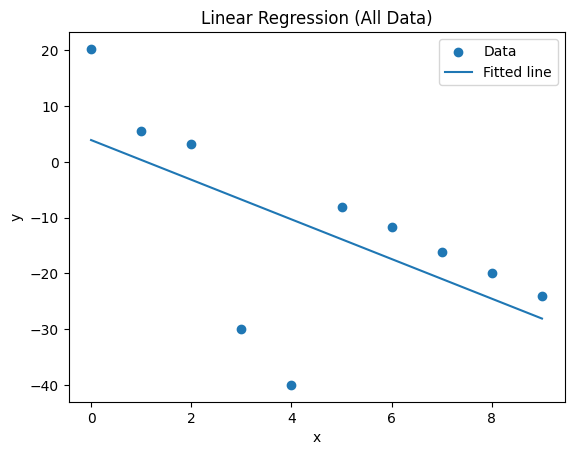

In [1]:
# Linear regression on the given dataset (scikit-learn)
# y = a + b x  with OLS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Data from Table 1 ---
x = np.array([0,1,2,3,4,5,6,7,8,9], dtype=float)
y = np.array([20.26, 5.61, 3.14, -30.00, -40.00, -8.13, -11.73, -16.08, -19.95, -24.03], dtype=float)

# --- Fit linear model ---
X = x.reshape(-1, 1)                       # scikit-learn expects 2D features
model = LinearRegression().fit(X, y)

a = float(model.intercept_)                # intercept
b = float(model.coef_[0])                  # slope
r2 = r2_score(y, model.predict(X))         # goodness of fit

print(f"Model: y = {a:.4f} + {b:.4f} * x")
print(f"R^2: {r2:.4f}")

# --- Plot scatter + fitted line ---
x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_line, y_line, label="Fitted line")
plt.title("Linear Regression (All Data)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


**Calculating Loss for the given values of Beta**

In [3]:
import pandas as pd
x = np.array([0,1,2,3,4,5,6,7,8,9], dtype=float)
y = np.array([20.26, 5.61, 3.14, -30.00, -40.00, -8.13, -11.73, -16.08, -19.95, -24.03], dtype=float)
N = len(x)

def yhat_m1(x):
    return -4.0*x + 12.0
def yhat_m2(x):
    return -3.55*x + 3.91


def robust_loss(y_true, y_pred, beta):
    resid2 = (y_true - y_pred)**2
    return float(np.mean(resid2 / (resid2 + beta**2)))

betas = [1.0, 1e-6, 1e3]

results=[]
for name,pred in [("Model 1: y = -4x + 12", yhat_m1(x)), ("Model 2: y = -3.55x + 3.91", yhat_m2(x)),]:
  for b in betas:
    L=robust_loss(y,pred,b)
    results.append({"Model":name,"beta":b,"L(theta,beta)":L})

df=pd.DataFrame(results)
print(df.to_string(index=False))







                     Model        beta  L(theta,beta)
     Model 1: y = -4x + 12    1.000000       0.435416
     Model 1: y = -4x + 12    0.000001       1.000000
     Model 1: y = -4x + 12 1000.000000       0.000227
Model 2: y = -3.55x + 3.91    1.000000       0.972847
Model 2: y = -3.55x + 3.91    0.000001       1.000000
Model 2: y = -3.55x + 3.91 1000.000000       0.000188


**Chosing a suitable value for Beta**

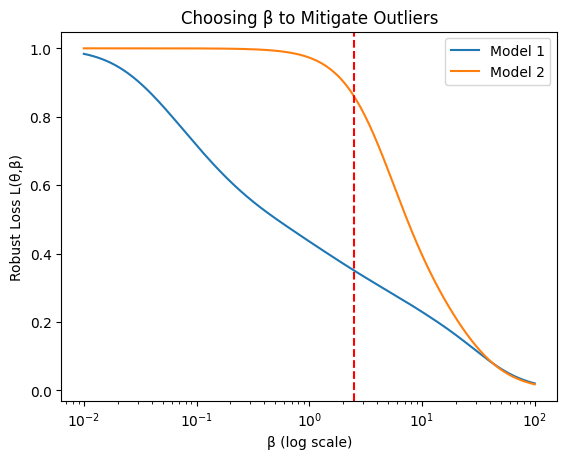

In [4]:
x = np.array([0,1,2,3,4,5,6,7,8,9], dtype=float)
y = np.array([20.26, 5.61, 3.14, -30.00, -40.00, -8.13, -11.73, -16.08, -19.95, -24.03], dtype=float)

betas = np.logspace(-2, 2, 200)  # from 0.01 to 100
loss_m1 = [robust_loss(y, yhat_m1(x), b) for b in betas]
loss_m2 = [robust_loss(y, yhat_m2(x), b) for b in betas]

plt.figure()
plt.semilogx(betas, loss_m1, label="Model 1")
plt.semilogx(betas, loss_m2, label="Model 2")
plt.axvline(2.5, color="red", linestyle="--")
plt.xlabel("β (log scale)")
plt.ylabel("Robust Loss L(θ,β)")
plt.title("Choosing β to Mitigate Outliers")
plt.legend()
plt.show()

I choose **β ≈ 2.5** because it provides the right balance between treating normal data points fairly and suppressing the effect of extreme outliers. In this context, residuals are simply the differences between the true observed values and the model’s predicted values
. Most residuals are small, but a few points (like those at x=3 and x=4) have very large residuals, making them outliers—data points that deviate strongly from the overall pattern. To measure the typical size of “normal” residuals without being distorted by these outliers, we use the median absolute deviation (MAD), which is a robust statistic that finds the median of the absolute deviations from the median residual. For our data, this gave a scale of about 1.26. By choosing β about twice this scale (≈ 2.5), the robust loss function behaves quadratically (like ordinary least squares) for small residuals, keeping genuine points influential, but it flattens out for very large residuals, effectively saturating their contribution so they no longer dominate the fit. Thus, β ≈ 2.5 is chosen because it anchors the model to the bulk of the data while neutralizing the leverage of the outliers.

**Determining the most suitable model using Beta=2.5**

In [5]:
beta=2.5

m1_loss = robust_loss(y, yhat_m1(x), beta)
m2_loss = robust_loss(y, yhat_m2(x), beta)

print(f"Model 1 loss at beta: {m1_loss:.6f}")
print(f"Model 2 loss at beta: {m2_loss:.6f}")
print("Better model:", "Model 1" if m1_loss < m2_loss else "Model 2")

Model 1 loss at beta: 0.350351
Model 2 loss at beta: 0.859301
Better model: Model 1


**How does this robust estimator reduce the impact of the outliers?**

This robust estimator reduces the impact of outliers by modifying how errors (called residuals, the differences between the true values and the model’s predictions) contribute to the overall loss. In ordinary least squares, the loss grows quadratically with residual size, so a few very large errors can dominate the fit and pull the regression line toward them. In contrast, the robust loss function we are using has a saturating form: when the residual is small compared to the chosen scale parameter β, the loss behaves like the usual squared error, meaning normal points still influence the model strongly. However, when the residual is much larger than β, the loss approaches a fixed upper bound and its gradient (the “pull” on the model during optimization) shrinks toward zero. This means that extreme points, or outliers, cannot keep increasing their influence as their error grows — their contribution flattens out and they are effectively down-weighted. As a result, the model focuses on fitting the majority of the data (the inliers), while the outliers are largely ignored.

**Another loss function that can be used instead**

Another widely used loss function for robust estimation is the **Huber loss**. The Huber loss behaves like the squared error for small residuals (so it keeps high sensitivity to inliers) but switches to a linear growth for large residuals (so it limits the influence of outliers). Formally, if
𝑒
e is the residual and
𝛿
δ is a threshold parameter, the Huber loss is defined as:




    0.5 * e^2                    if |e| ≤ δ

    δ * (|e| - 0.5 * δ)          if |e| > δ





This makes the Huber loss quadratic near zero (preserving efficiency for inliers) and linear for large errors (down-weighting outliers). Because of this balance, it is often used in robust regression as an alternative to Geman–McClure, and it can be tuned via the threshold
𝛿
δ to control how aggressively outliers are suppressed.



---



# 2. Loss Function

True y = 1	Prediction ŷ	MSE		BCE
1		0.005		0.990025	5.298317
1		0.010		0.980100	4.605170
1		0.050		0.902500	2.995732
1		0.100		0.810000	2.302585
1		0.200		0.640000	1.609438
1		0.300		0.490000	1.203973
1		0.400		0.360000	0.916291
1		0.500		0.250000	0.693147
1		0.600		0.160000	0.510826
1		0.700		0.090000	0.356675
1		0.800		0.040000	0.223144
1		0.900		0.010000	0.105361
1		1.000		0.000000	0.000000


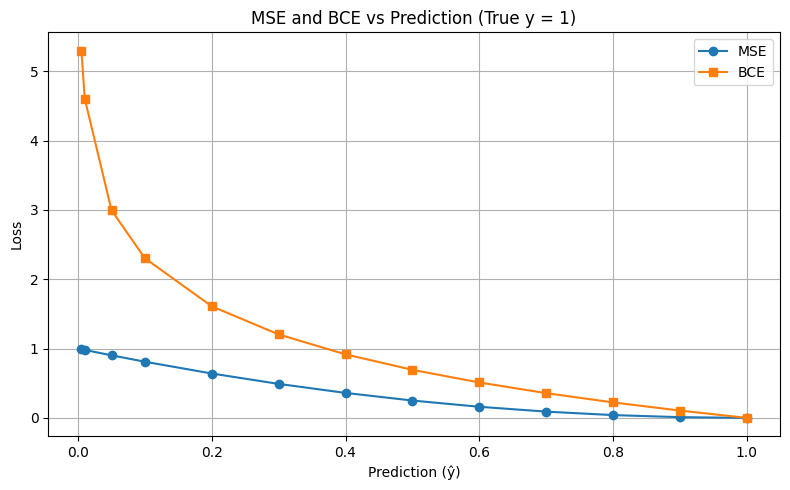

In [7]:
from sklearn.metrics import mean_squared_error, log_loss

y_hat = np.array([0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4,
                  0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
y_true =np.ones(13)

mse_vals = (y_true - y_hat)**2

# Clip predictions to avoid log(0)
eps = 1e-12
y_hat_clipped = np.clip(y_hat, eps, 1 - eps)

bce_vals = - (y_true * np.log(y_hat_clipped) + (1 - y_true) * np.log(1 - y_hat_clipped))

print("True y = 1\tPrediction ŷ\tMSE\t\tBCE")
for y, p, m, b in zip(y_true, y_hat, mse_vals, bce_vals):
    print(f"{int(y)}\t\t{p:.3f}\t\t{m:.6f}\t{b:.6f}")



# Plot
plt.figure(figsize=(8, 5))
plt.plot(y_hat, mse_vals, label="MSE", marker='o')
plt.plot(y_hat, bce_vals, label="BCE", marker='s')
plt.title("MSE and BCE vs Prediction (True y = 1)")
plt.xlabel("Prediction (ŷ)")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




**Chosing the suitable loss function**

For **Application 1**, where the dependent variable is continuous, the appropriate loss function is **Mean Squared Error** (MSE). MSE measures the average of the squares of the differences between the true and predicted values. It is well-suited for regression tasks because it assumes that the prediction errors are normally distributed and penalizes larger errors more heavily due to the squaring. This aligns with the goal of linear regression, which seeks to find a line that minimizes the squared deviations between predicted outputs and actual values in continuous space.

In contrast, **Application 2** involves a binary dependent variable
𝑦
∈
{
0
,
1
}
, which makes **Binary Cross-Entropy** (BCE) the more appropriate loss function. BCE, also known as log loss, is derived from the likelihood function under a Bernoulli distribution and measures how well a probabilistic classifier (like logistic regression) predicts the true class. Unlike MSE, BCE takes into account the confidence of the prediction by heavily penalizing confident but wrong predictions. Logistic regression outputs probabilities between 0 and 1, and BCE effectively evaluates how close those probabilities are to the true binary labels. Using MSE in this context would not correctly model the underlying probability distribution and can lead to suboptimal decision boundaries and poorly calibrated outputs. Therefore, MSE is best for continuous targets in Application 1, and BCE is best for binary classification in Application 2.



---



# Data Preprocessing

**Generating the 2 features**

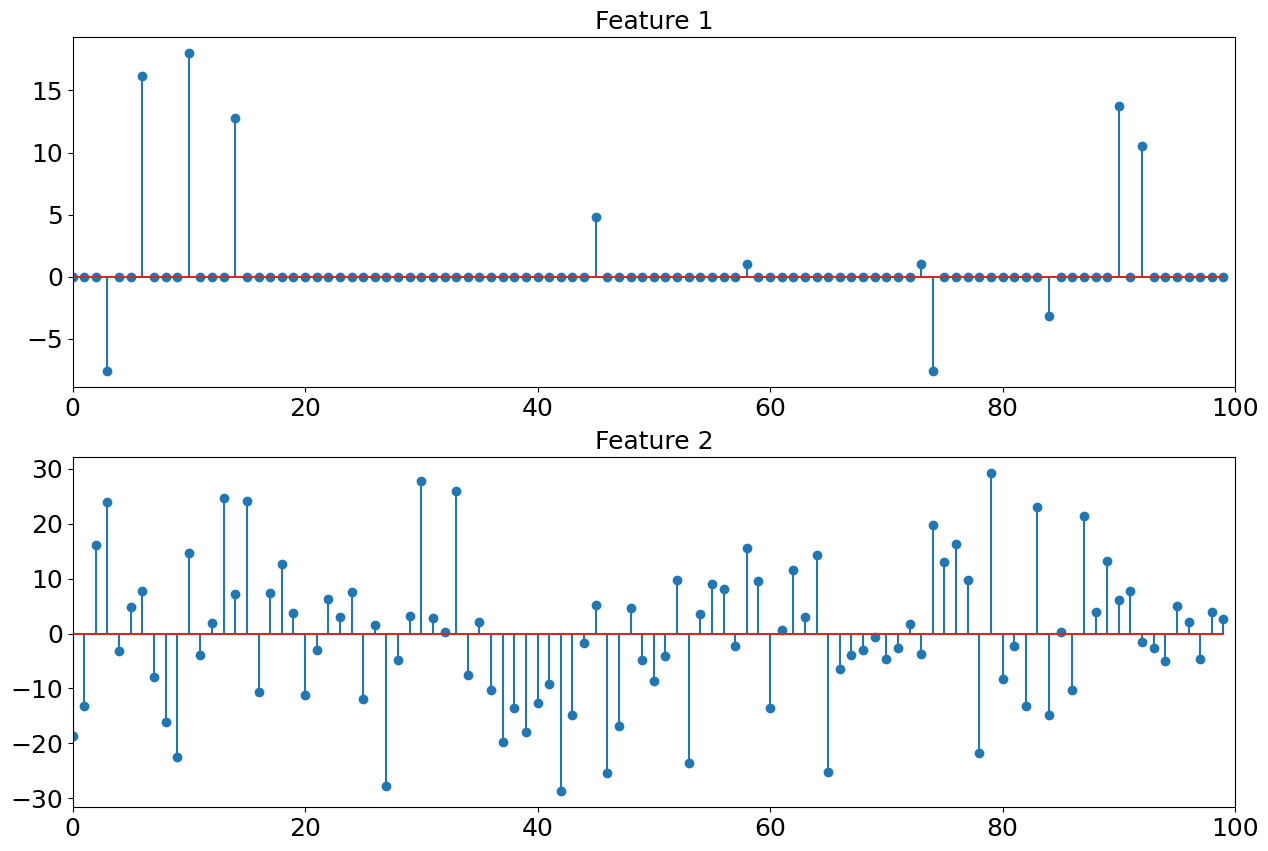

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def generate_signal(signal_length, num_nonzero):

  signal = np.zeros(signal_length)
  nonzero_indices = np.random.choice(signal_length, num_nonzero,replace=False)
  nonzero_values = 10*np.random.randn(num_nonzero)
  signal[nonzero_indices] = nonzero_values

  return signal

signal_length = 100 # Total length of the signal
num_nonzero = 10 # Number of non-zero elements in thesignal
your_index_no= 220454 # Enter your index no without english letters and without leading zeros

sparse_signal = generate_signal(signal_length, num_nonzero)
sparse_signal[10] = (your_index_no % 10)*2 + 10
if your_index_no % 10 == 0:
 sparse_signal[10] = np.random.randn(1) + 30
 sparse_signal=sparse_signal/5

epsilon = np.random.normal(0, 15, signal_length )

plt.figure(figsize=(15,10))
plt.subplot(2, 1, 1)
plt.xlim(0, signal_length)
plt.title("Feature 1", fontsize=18)
plt.xticks(fontsize=18) # Adjust x-axis tick label font size
plt.yticks(fontsize=18)
plt.stem(sparse_signal)
plt.subplot(2, 1, 2)
plt.xlim(0, signal_length)
plt.title("Feature 2", fontsize=18)
plt.stem(epsilon)
plt.xticks(fontsize=18) # Adjust x-axis tick label font size
plt.yticks(fontsize=18)
plt.show()



**Finding the most suitable scaling method**

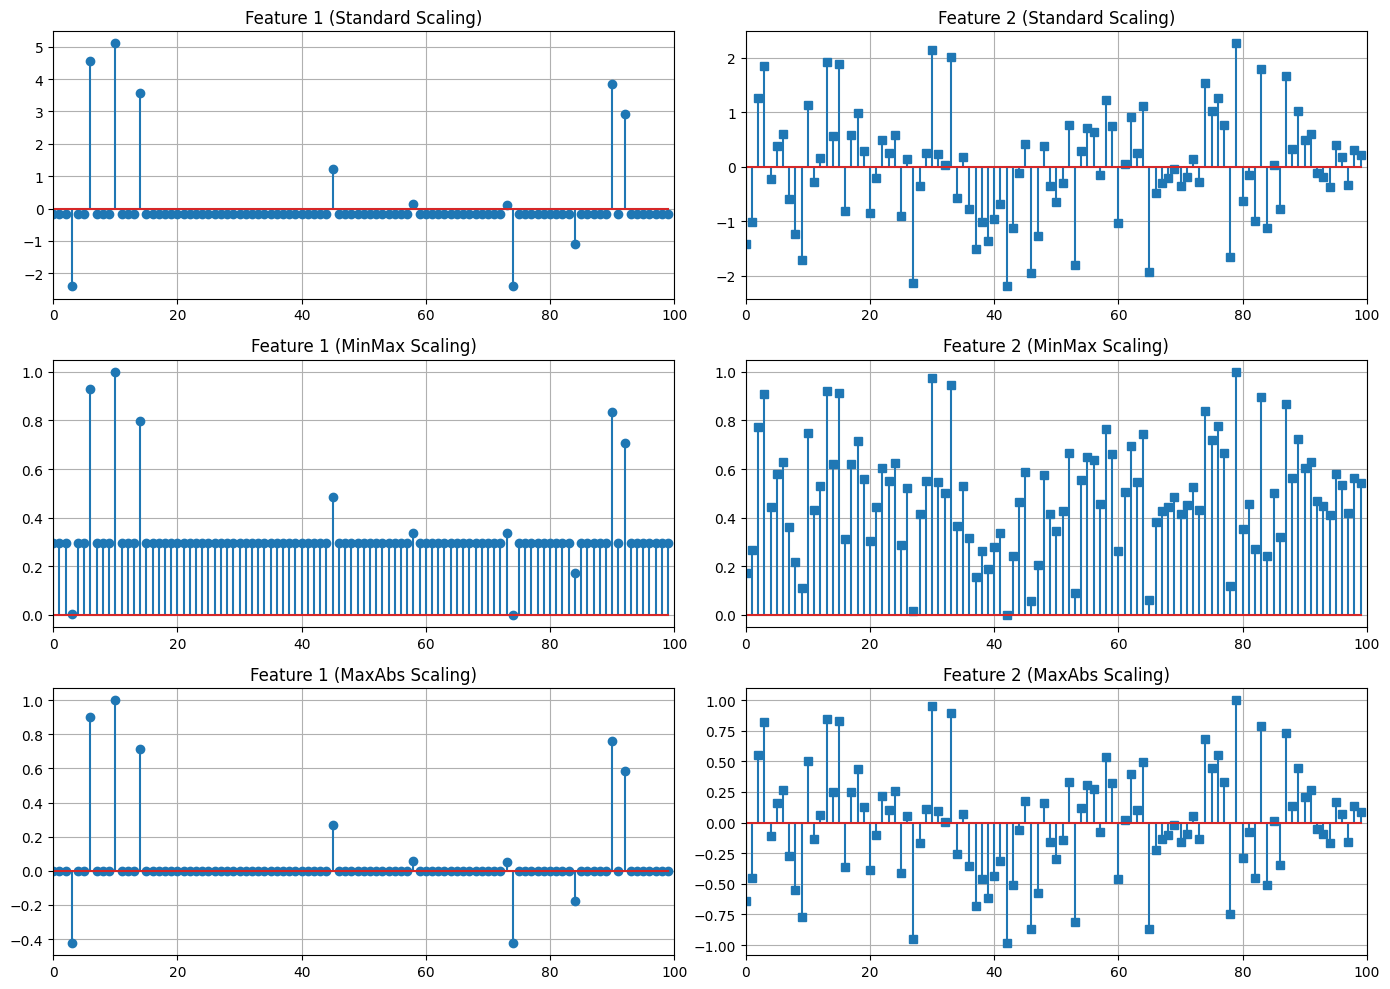

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "MaxAbs": MaxAbsScaler()
}

scaled_results={}
for name,scaler in scalers.items():
  f1_scaled=scaler.fit_transform(sparse_signal.reshape(-1,1)).flatten()
  f2_scaled=scaler.fit_transform(epsilon.reshape(-1,1)).flatten()
  scaled_results[name]=(f1_scaled,f2_scaled)

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
scaling_names = list(scaled_results.keys())

for i,name in enumerate(scaling_names):
  f1,f2=scaled_results[name]
  axs[i, 0].stem(np.arange(signal_length), f1, markerfmt='o')
  axs[i, 0].set_title(f"Feature 1 ({name} Scaling)")
  axs[i, 1].stem(np.arange(signal_length), f2, markerfmt='s')
  axs[i, 1].set_title(f"Feature 2 ({name} Scaling)")

for ax_row in axs:
    for ax in ax_row:
        ax.set_xlim(0, signal_length)
        ax.grid(True)

plt.tight_layout()
plt.show()

In [12]:
summary = {}
for name, (f1, f2) in scaled_results.items():
    summary[name] = {
        "F1 Min": np.min(f1),
        "F1 Max": np.max(f1),
        "F1 Std": np.std(f1),
        "F2 Min": np.min(f2),
        "F2 Max": np.max(f2),
        "F2 Std": np.std(f2)
    }

df = pd.DataFrame(summary).T
print("\n=== Scaling Summary ===")
print(df.round(3))


=== Scaling Summary ===
          F1 Min  F1 Max  F1 Std  F2 Min  F2 Max  F2 Std
Standard  -2.408   5.101   1.000  -2.198   2.267   1.000
MinMax     0.000   1.000   0.133   0.000   1.000   0.224
MaxAbs    -0.423   1.000   0.190  -0.984   1.000   0.444


**Justification:**

For **Feature 1**, which is a sparse signal containing mostly zeros with a few large non-zero spikes, the most appropriate scaling method is **MaxAbs Scaling**. MaxAbsScaler scales the data by dividing each value by the maximum absolute value of the feature, without changing the location of zero. This is particularly important for sparse or one-hot encoded data, as it preserves the sparsity (keeps zeros as zeros) and maintains the relative magnitude of non-zero entries. Other methods like StandardScaler or MinMaxScaler shift the data around zero or to a fixed range (like [0, 1]), which can destroy the sparse structure by turning many zeros into small non-zero values. MaxAbs scaling ensures that the signal's structure — namely, the positions and relative strengths of the few meaningful spikes — remains intact, making it the best choice for a sparse feature.

For **Feature 2**, which is a dense and normally distributed noise signal (generated from a Gaussian distribution with mean 0 and standard deviation 15), the most suitable scaling method is **Standard Scaling** (Z-score normalization). StandardScaler transforms the data to have a mean of 0 and a standard deviation of 1, which is ideal when the original data is Gaussian-like or symmetric. This kind of scaling is commonly preferred for many machine learning algorithms such as logistic regression, SVMs, and PCA, because it standardizes the feature’s scale and removes bias due to differing units or magnitudes. Since the noise is already naturally spread around 0, standard scaling will preserve its distributional shape while normalizing its scale, making it easier to compare or combine with other features in downstream models.